In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
print("Libraries loaded.")


Libraries loaded.


In [3]:
df = pd.read_csv(r"C:\Users\ARYAN\Downloads\city_day.csv\city_day.csv")
df['Date'] = pd.to_datetime(df['Date'])
print("Shape:", df.shape)
print("Cities:", df['City'].nunique())
df.head()


Shape: (29531, 16)
Cities: 26


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

In [5]:
print("Missing values (%):")
(df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)

Missing values (%):


Xylene        61.32
PM10          37.72
NH3           34.97
Toluene       27.23
Benzene       19.04
AQI           15.85
AQI_Bucket    15.85
PM2.5         15.57
NOx           14.17
O3            13.62
SO2           13.05
NO2           12.14
NO            12.13
CO             6.97
City           0.00
Date           0.00
dtype: float64

In [6]:
jaipur = df[df['City'] == 'Jaipur'].sort_values('Date').reset_index(drop=True)
print("Jaipur records:", jaipur.shape)
print("Date range:", jaipur['Date'].min().date(), "to", jaipur['Date'].max().date())
jaipur.describe()

Jaipur records: (1114, 16)
Date range: 2017-06-14 to 2020-07-01


,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,1114,1102.000000,1100.000000,1098.000000,1100.000000,1002.000000,1099.000000,1107.000000,1102.000000,1099.000000,1092.000000,1091.000000,0.0,1094.000000
mean,2018-12-22 12:00:00,54.500708,123.483509,14.632987,32.418627,39.637176,26.513494,0.800894,11.071062,46.715469,1.571172,6.685573,NaN,133.679159
min,2017-06-14 00:00:00,9.120000,0.420000,0.440000,0.010000,6.040000,0.340000,0.000000,3.200000,0.240000,0.000000,0.000000,NaN,43.000000
25%,2018-03-19 06:00:00,36.300000,86.357500,7.005000,21.155000,26.345000,18.180000,0.620000,9.290000,32.640000,0.480000,2.290000,NaN,96.000000
50%,2018-12-22 12:00:00,49.750000,116.825000,10.525000,29.735000,34.585000,23.530000,0.770000,10.735000,45.680000,0.990000,4.720000,NaN,122.000000
75%,2019-09-26 18:00:00,67.130000,153.072500,15.802500,40.365000,47.077500,30.955000,0.960000,12.535000,59.070000,2.060000,9.210000,NaN,159.000000
max,2020-07-01 00:00:00,311.350000,491.010000,100.510000,118.920000,135.910000,87.280000,2.740000,27.320000,172.280000,13.640000,37.110000,NaN,457.000000
std,NaN,26.551826,54.948563,13.454424,15.640016,20.624056,13.202486,0.391905,2.919111,21.121277,1.726622,6.259888,NaN,54.309341


In [7]:
print("Missing values in Jaipur subset (%):")
(jaipur.isna().sum() / len(jaipur) * 100).round(2).sort_values(ascending=False)

Missing values in Jaipur subset (%):


Xylene        100.00
NOx            10.05
Toluene         2.06
Benzene         1.97
AQI             1.80
AQI_Bucket      1.80
NO              1.44
NH3             1.35
O3              1.35
PM10            1.26
NO2             1.26
PM2.5           1.08
SO2             1.08
CO              0.63
City            0.00
Date            0.00
dtype: float64

In [8]:
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

jaipur_clean = jaipur.copy()
jaipur_clean = jaipur_clean.set_index('Date')

# Time-based interpolation (limit=7 -> don't bridge gaps longer than a week)
for col in pollutant_cols + ['AQI']:
    jaipur_clean[col] = jaipur_clean[col].interpolate(method='time', limit=7)

jaipur_clean = jaipur_clean.reset_index()

# Drop rows where AQI is still missing (target variable, can't fabricate it)
before = len(jaipur_clean)
jaipur_clean = jaipur_clean.dropna(subset=['AQI'])
print(f"Dropped {before - len(jaipur_clean)} rows with unrecoverable missing AQI")
print("Final shape:", jaipur_clean.shape)

# Recompute AQI_Bucket for any rows where interpolation filled AQI but bucket is still NaN
def aqi_bucket(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else: return 'Severe'

jaipur_clean['AQI_Bucket'] = jaipur_clean['AQI_Bucket'].fillna(jaipur_clean['AQI'].apply(aqi_bucket))
jaipur_clean.isna().sum()

Dropped 6 rows with unrecoverable missing AQI
Final shape: (1108, 16)


Date             0
City             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx            106
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene        1108
AQI              0
AQI_Bucket       0
dtype: int64

In [9]:
jaipur_clean['Year'] = jaipur_clean['Date'].dt.year
jaipur_clean['Month'] = jaipur_clean['Date'].dt.month
jaipur_clean['MonthName'] = jaipur_clean['Date'].dt.month_name()

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

jaipur_clean['Season'] = jaipur_clean['Month'].apply(get_season)
jaipur_clean[['Date','Year','Month','Season','AQI','AQI_Bucket']].head()


,Date,Year,Month,Season,AQI,AQI_Bucket
6,2017-06-20,2017,6,Monsoon,149.0,Moderate
7,2017-06-21,2017,6,Monsoon,126.0,Moderate
8,2017-06-22,2017,6,Monsoon,85.0,Satisfactory
9,2017-06-23,2017,6,Monsoon,62.0,Satisfactory
10,2017-06-24,2017,6,Monsoon,77.0,Satisfactory


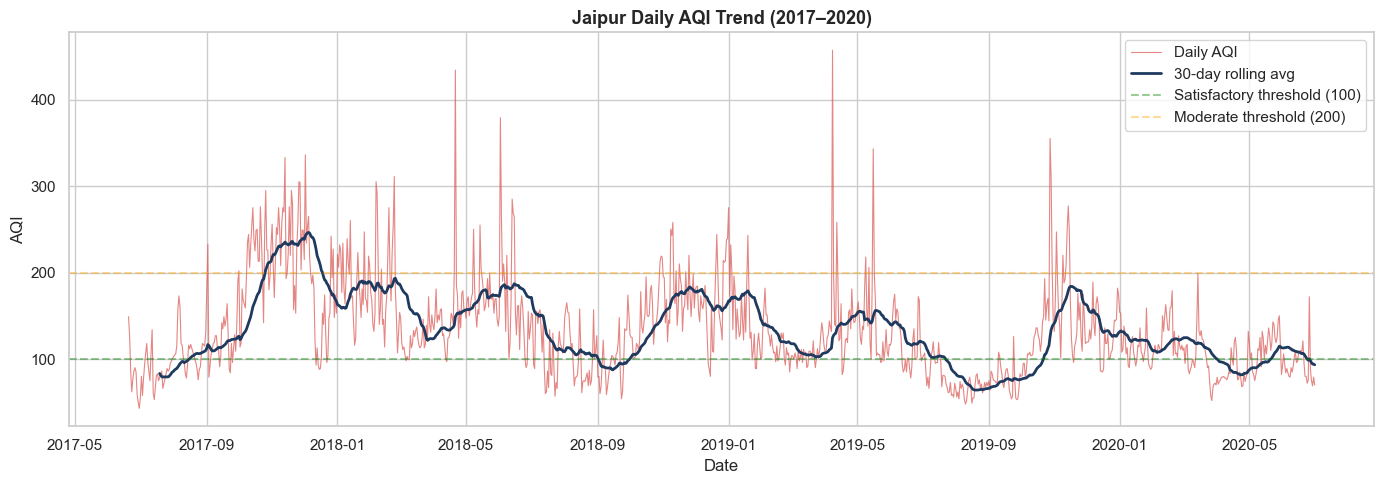

In [10]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(jaipur_clean['Date'], jaipur_clean['AQI'], color='#d9534f', linewidth=0.8, alpha=0.7, label='Daily AQI')
ax.plot(jaipur_clean['Date'], jaipur_clean['AQI'].rolling(30).mean(), color='#1f3a5f', linewidth=2, label='30-day rolling avg')
ax.axhline(100, color='green', linestyle='--', alpha=0.4, label='Satisfactory threshold (100)')
ax.axhline(200, color='orange', linestyle='--', alpha=0.4, label='Moderate threshold (200)')
ax.set_title('Jaipur Daily AQI Trend (2017–2020)')
ax.set_xlabel('Date'); ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.show()

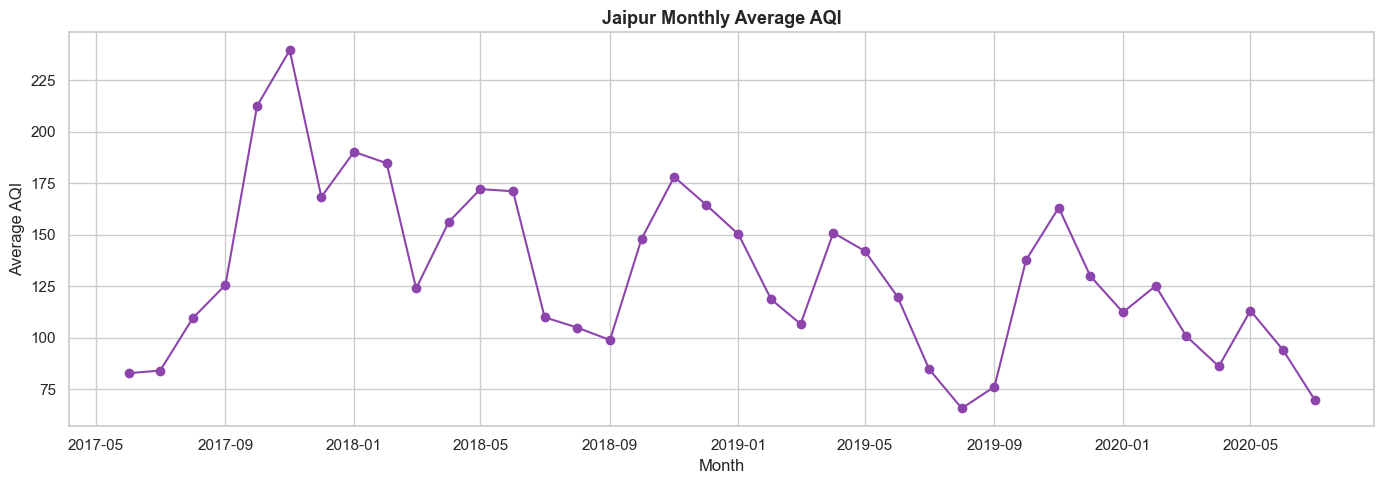

In [11]:
monthly_avg = jaipur_clean.groupby(['Year','Month'])['AQI'].mean().reset_index()
monthly_avg['Date'] = pd.to_datetime(monthly_avg[['Year','Month']].assign(DAY=1))

plt.figure(figsize=(14,5))
plt.plot(monthly_avg['Date'], monthly_avg['AQI'], marker='o', color='#8e44ad')
plt.title('Jaipur Monthly Average AQI')
plt.xlabel('Month'); plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

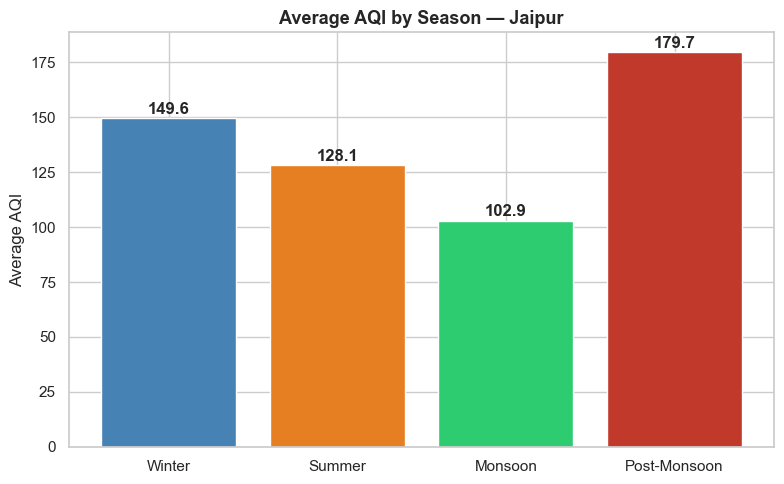

Season
Winter          149.560886
Summer          128.065217
Monsoon         102.949735
Post-Monsoon    179.685792
Name: AQI, dtype: float64

In [12]:
season_order = ['Winter','Summer','Monsoon','Post-Monsoon']
season_avg = jaipur_clean.groupby('Season')['AQI'].mean().reindex(season_order)

plt.figure(figsize=(8,5))
bars = plt.bar(season_avg.index, season_avg.values, color=['#4682B4','#e67e22','#2ecc71','#c0392b'])
plt.title('Average AQI by Season — Jaipur')
plt.ylabel('Average AQI')
for bar, val in zip(bars, season_avg.values):
    plt.text(bar.get_x()+bar.get_width()/2, val+2, f'{val:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

season_avg

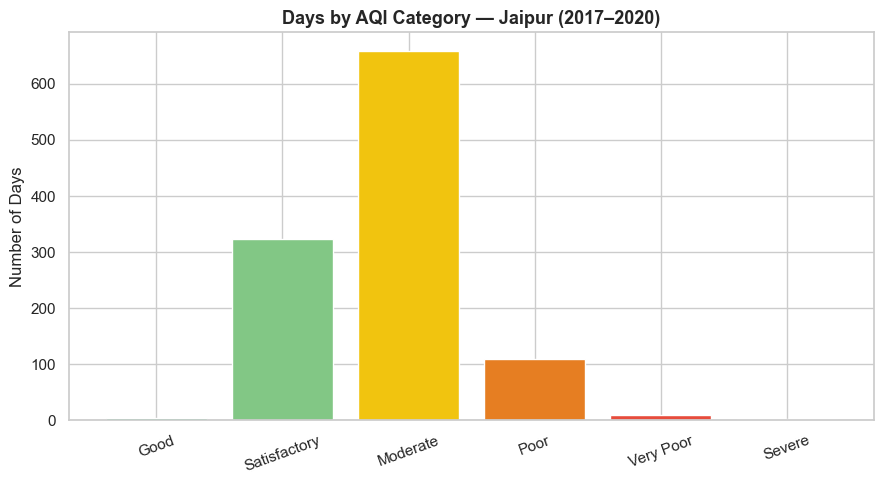

AQI_Bucket
Good             0.4%
Satisfactory    29.2%
Moderate        59.5%
Poor             9.9%
Very Poor        0.9%
Severe           0.2%
Name: count, dtype: object


In [13]:
bucket_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
bucket_counts = jaipur_clean['AQI_Bucket'].value_counts().reindex(bucket_order).fillna(0)

plt.figure(figsize=(9,5))
colors = ['#2ecc71','#82c785','#f1c40f','#e67e22','#e74c3c','#8b0000']
plt.bar(bucket_counts.index, bucket_counts.values, color=colors)
plt.title('Days by AQI Category — Jaipur (2017–2020)')
plt.ylabel('Number of Days')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print((bucket_counts / bucket_counts.sum() * 100).round(1).astype(str) + '%')

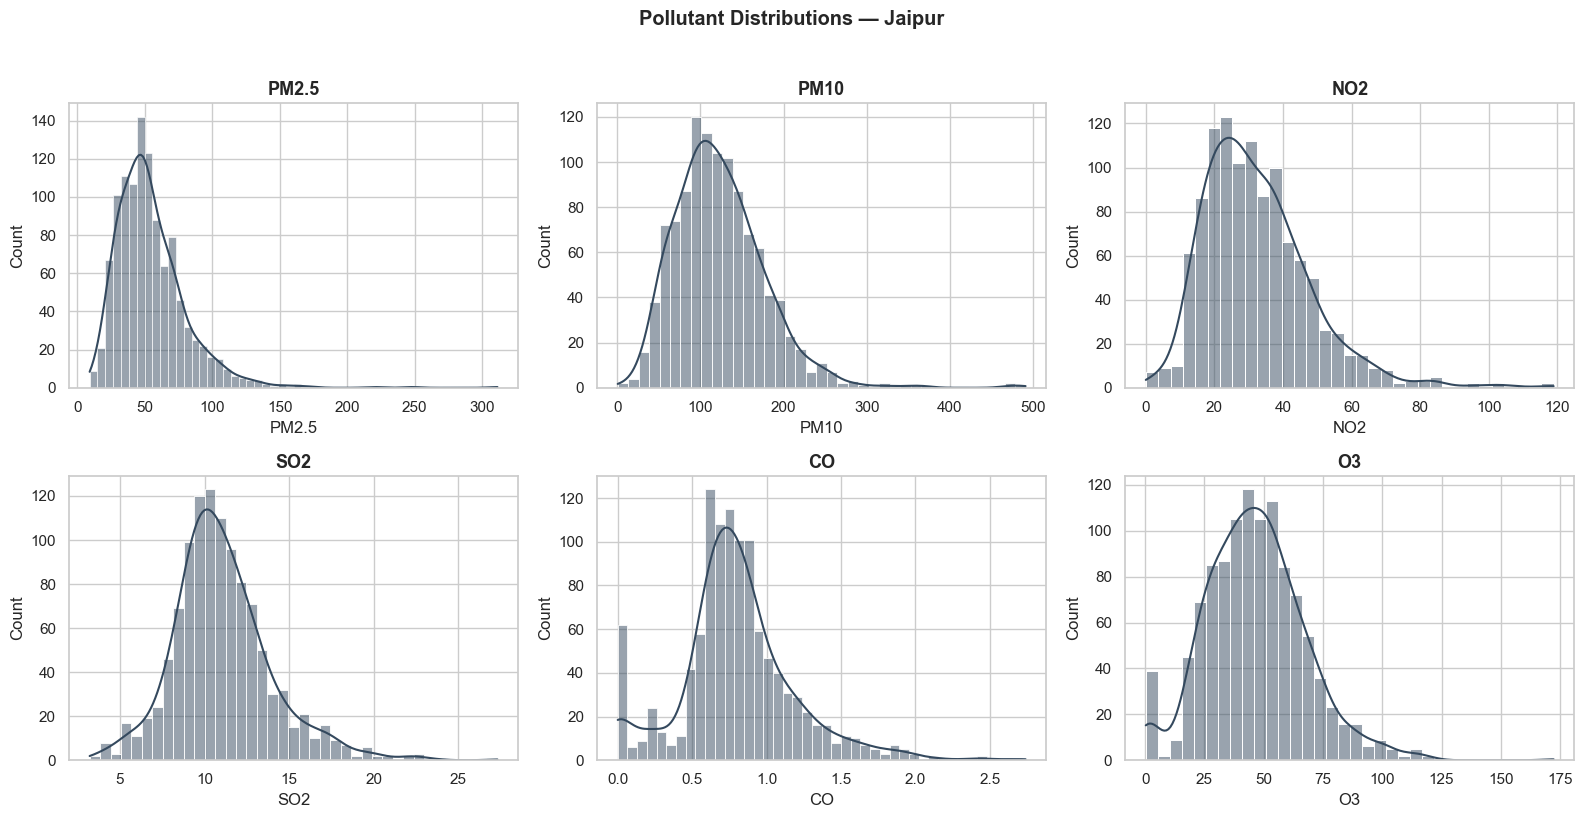

In [14]:
key_pollutants = ['PM2.5','PM10','NO2','SO2','CO','O3']
fig, axes = plt.subplots(2, 3, figsize=(16,8))
for ax, col in zip(axes.flatten(), key_pollutants):
    sns.histplot(jaipur_clean[col].dropna(), kde=True, ax=ax, color='#34495e')
    ax.set_title(col)
plt.suptitle('Pollutant Distributions — Jaipur', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

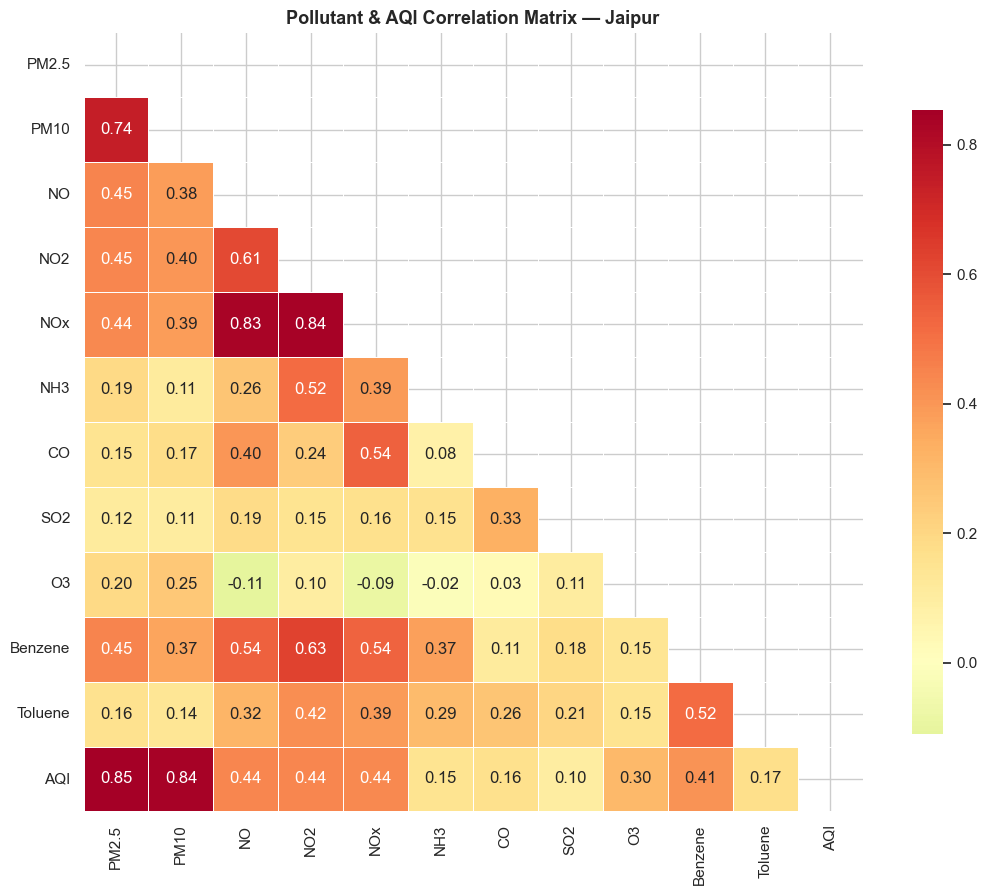

Top correlations with AQI:


PM2.5      0.853416
PM10       0.840535
NO2        0.444477
NO         0.441442
NOx        0.438997
Benzene    0.407521
O3         0.304151
Toluene    0.169823
CO         0.162294
NH3        0.146462
SO2        0.099414
Name: AQI, dtype: float64

In [15]:
model_pollutants = [c for c in pollutant_cols if c != 'Xylene']
corr_cols = model_pollutants + ['AQI']
corr_matrix = jaipur_clean[corr_cols].corr()

plt.figure(figsize=(11,9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Pollutant & AQI Correlation Matrix — Jaipur')
plt.tight_layout()
plt.show()

print("Top correlations with AQI:")
corr_matrix['AQI'].drop('AQI').sort_values(ascending=False)


In [16]:
winter_aqi = jaipur_clean[jaipur_clean['Season']=='Winter']['AQI'].dropna()
monsoon_aqi = jaipur_clean[jaipur_clean['Season']=='Monsoon']['AQI'].dropna()

t_stat, p_val = stats.ttest_ind(winter_aqi, monsoon_aqi, equal_var=False)

print(f"Winter mean AQI:  {winter_aqi.mean():.2f}  (n={len(winter_aqi)})")
print(f"Monsoon mean AQI: {monsoon_aqi.mean():.2f}  (n={len(monsoon_aqi)})")
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value:     {p_val:.2e}")
print(f"\nConclusion: {'Statistically significant difference (reject H0)' if p_val < 0.05 else 'No significant difference (fail to reject H0)'} at alpha=0.05")

Winter mean AQI:  149.56  (n=271)
Monsoon mean AQI: 102.95  (n=378)

t-statistic: 13.042
p-value:     8.65e-34

Conclusion: Statistically significant difference (reject H0) at alpha=0.05


In [17]:
contingency = pd.crosstab(jaipur_clean['Season'], jaipur_clean['AQI_Bucket'])
print("Contingency table:")
display(contingency)

chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_val_chi:.2e}")
print(f"\nConclusion: {'Season and AQI category are significantly associated (reject H0)' if p_val_chi < 0.05 else 'No significant association (fail to reject H0)'} at alpha=0.05")


Contingency table:


AQI_Bucket,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
Season,,,,,,
Monsoon,4,153,7,213,0,1
Post-Monsoon,0,113,58,7,0,5
Summer,0,196,7,70,2,1
Winter,0,197,38,33,0,3



Chi-square statistic: 356.759
Degrees of freedom:   15
p-value:              8.10e-67

Conclusion: Season and AQI category are significantly associated (reject H0) at alpha=0.05


In [18]:
season_groups = [jaipur_clean[jaipur_clean['Season']==s]['AQI'].dropna() for s in season_order]
f_stat, p_val_anova = stats.f_oneway(*season_groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value:     {p_val_anova:.2e}")
print(f"\nConclusion: {'At least one season has significantly different AQI (reject H0)' if p_val_anova < 0.05 else 'No significant difference across seasons'} at alpha=0.05")

F-statistic: 124.710
p-value:     1.46e-69

Conclusion: At least one season has significantly different AQI (reject H0) at alpha=0.05


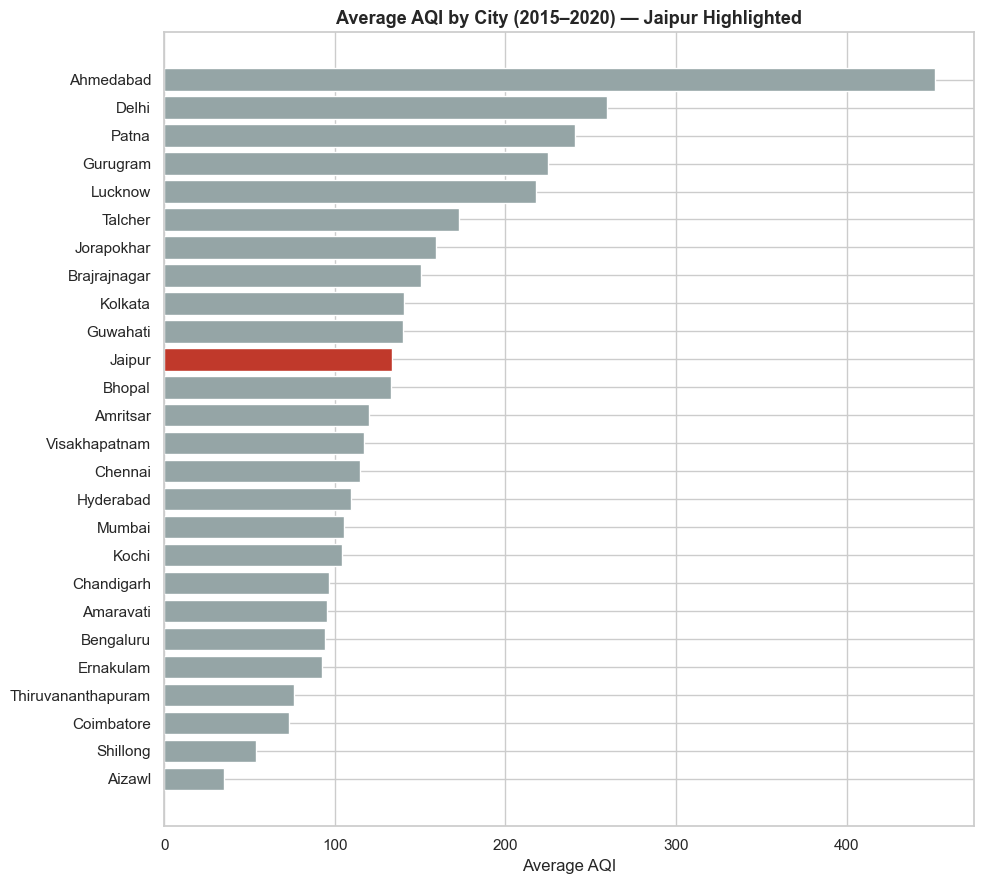

Jaipur's rank by avg AQI (1=worst): 11 out of 26 cities


In [19]:
city_avg_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,9))
colors = ['#c0392b' if city=='Jaipur' else '#95a5a6' for city in city_avg_aqi.index]
plt.barh(city_avg_aqi.index, city_avg_aqi.values, color=colors)
plt.title('Average AQI by City (2015–2020) — Jaipur Highlighted')
plt.xlabel('Average AQI')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

rank = (city_avg_aqi.reset_index().reset_index().rename(columns={'index':'Rank'}))
rank['Rank'] += 1
print(f"Jaipur's rank by avg AQI (1=worst): {rank[rank.City=='Jaipur']['Rank'].values[0]} out of {len(rank)} cities")

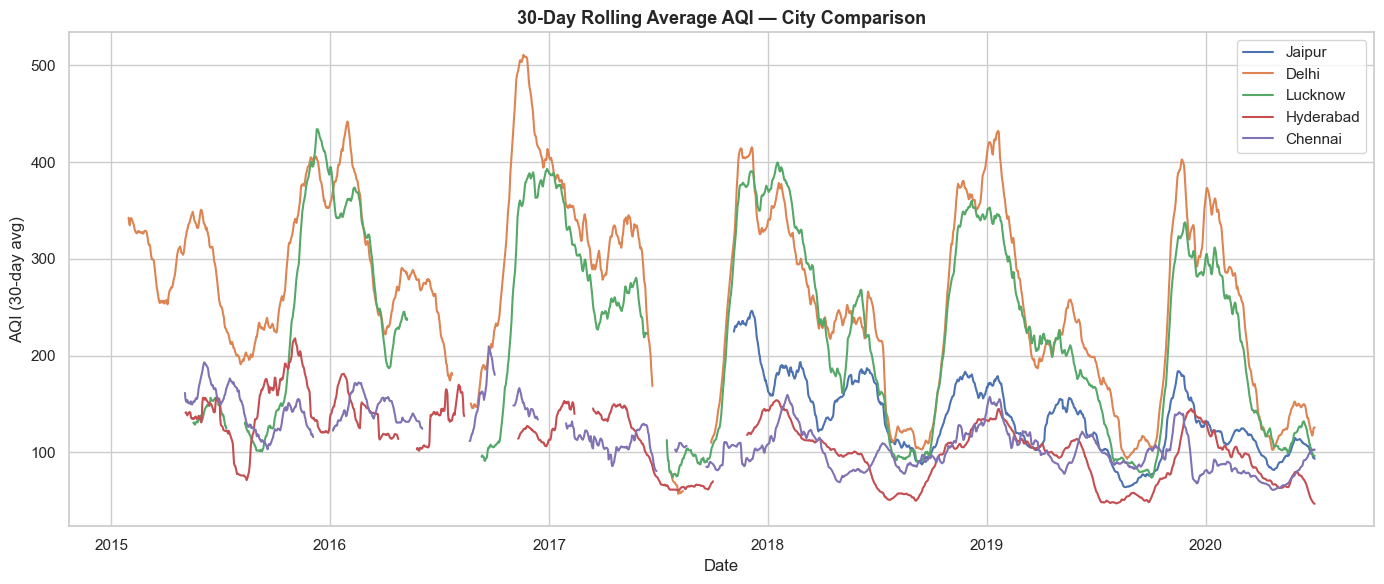

In [20]:
compare_cities = ['Jaipur', 'Delhi', 'Lucknow', 'Hyderabad', 'Chennai']
compare_df = df[df['City'].isin(compare_cities)]

plt.figure(figsize=(14,6))
for city in compare_cities:
    city_data = compare_df[compare_df['City']==city].sort_values('Date')
    plt.plot(city_data['Date'], city_data['AQI'].rolling(30).mean(), label=city, linewidth=1.5)

plt.title('30-Day Rolling Average AQI — City Comparison')
plt.xlabel('Date'); plt.ylabel('AQI (30-day avg)')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
model_df = jaipur_clean.dropna(subset=model_pollutants + ['AQI'])
X = model_df[model_pollutants]
y = model_df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"R² score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")


R² score: 0.881
MAE:      13.82
Train samples: 801 | Test samples: 201


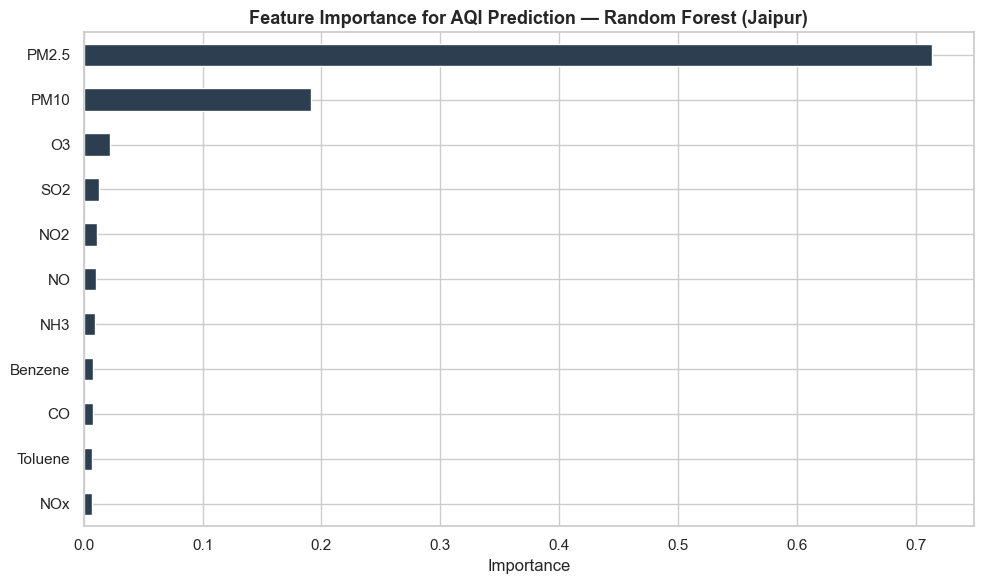

PM2.5      0.713011
PM10       0.190816
O3         0.022172
SO2        0.013239
NO2        0.011112
NO         0.010195
NH3        0.009281
Benzene    0.008110
CO         0.007545
Toluene    0.007449
NOx        0.007071
dtype: float64

In [22]:
importances = pd.Series(rf.feature_importances_, index=model_pollutants).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='#2c3e50')
plt.title('Feature Importance for AQI Prediction — Random Forest (Jaipur)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

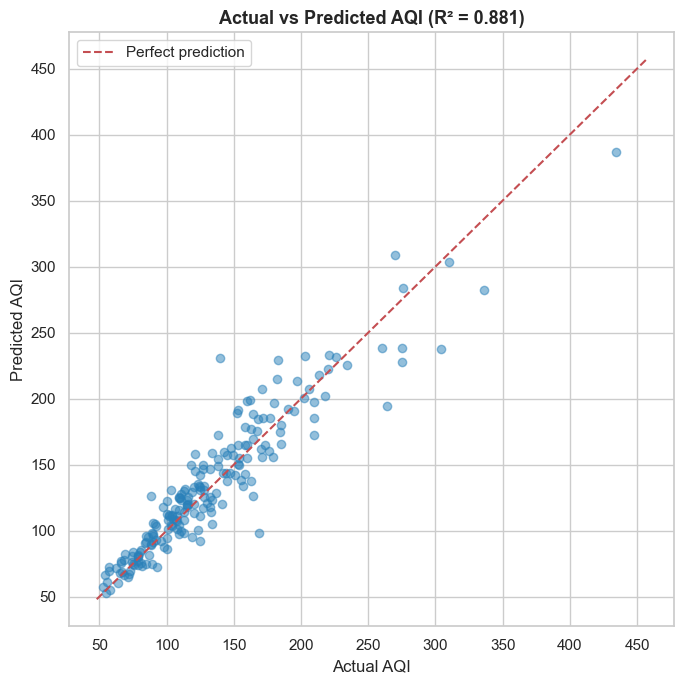

In [23]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, color='#2980b9')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual AQI'); plt.ylabel('Predicted AQI')
plt.title(f'Actual vs Predicted AQI (R² = {r2_score(y_test, y_pred):.3f})')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
jaipur_clean.to_csv('jaipur_aqi_cleaned.csv', index=False)
print("Saved: jaipur_aqi_cleaned.csv")
print(jaipur_clean.shape)
jaipur_clean.head()


Saved: jaipur_aqi_cleaned.csv
(1108, 20)


,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,MonthName,Season
6,2017-06-20,Jaipur,70.10,75.55,10.55,6.16,NaN,8.17,0.81,9.02,13.83,0.0,0.26,NaN,149.0,Moderate,2017,6,June,Monsoon
7,2017-06-21,Jaipur,67.50,93.80,10.29,2.98,NaN,5.10,0.71,9.26,38.19,0.0,0.33,NaN,126.0,Moderate,2017,6,June,Monsoon
8,2017-06-22,Jaipur,24.80,31.95,10.17,3.11,NaN,5.04,0.74,8.89,44.67,0.0,0.33,NaN,85.0,Satisfactory,2017,6,June,Monsoon
9,2017-06-23,Jaipur,32.30,47.40,9.64,3.27,NaN,3.80,0.68,8.39,39.16,0.0,0.17,NaN,62.0,Satisfactory,2017,6,June,Monsoon
10,2017-06-24,Jaipur,55.36,73.69,32.81,1.68,NaN,13.26,0.77,9.33,10.76,0.0,0.00,NaN,77.0,Satisfactory,2017,6,June,Monsoon


Key Findings Summary

1. Data quality: Jaipur has 1,114 daily records (Jun 2017 – Jul 2020) from CPCB monitoring. After time-based interpolation of short gaps, the dataset is largely complete and usable.
2. Seasonality: Winter shows the highest AQI (temperature inversion + regional stubble burning), Monsoon the lowest (rain washout). Both t-test and ANOVA confirm this is statistically significant, not random noise.
3. Category dependence: Chi-square test confirms AQI category (Good/Moderate/Poor/etc.) is significantly associated with season — supports building a "seasonal health advisory" feature in the dashboard.
4. Correlation: PM2.5 and PM10 are most strongly correlated with overall AQI, consistent with CPCB's AQI formula (dominant pollutant sub-index). NO2, NOx also show meaningful correlation (traffic emissions).
5. City standing: Jaipur's average AQI positions it in the moderate-to-poor tier among the 26 cities in this dataset — worse than southern cities (Chennai, Bengaluru), better than Delhi/NCR cities.
6. Predictability: A baseline Random Forest achieves a strong R² on held-out data using pollutant concentrations alone — confirming AQI is well-predictable from PM2.5/PM10/NO2, which will be the core features for the production prediction API.